In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2


In [7]:
# SETUP DATASET PATHS AND EXTRACTION
import os
import shutil

def setup_dataset():
    if not os.path.exists('/content'):
        print('Running locally on PC.')
        return './dataset2-master/dataset2-master/images/'

    print('Running in Google Colab.')

    # Function to automatically search for the TRAIN folder
    def find_base_dir():
        if os.path.exists('/content/dataset'):
            for root, dirs, files in os.walk('/content/dataset'):
                if 'TRAIN' in dirs:
                    return root
        return None

    # Step 1: See if we already extracted it correctly
    base_dir = find_base_dir()
    if base_dir:
        print('Dataset is ready!')
        return base_dir

    # Step 2: If not found, we need to extract from scratch
    print('Dataset not extracted yet. Extracting now... (Please wait)')

    # Delete the broken empty folder from earlier attempts
    if os.path.exists('/content/dataset'):
        shutil.rmtree('/content/dataset')
    os.makedirs('/content/dataset')

    # Extract the new dataset you uploaded
    if os.path.exists('/content/Blood_cell_data.zip'):
        print('Unzipping Blood_cell_data.zip...')
        os.system('unzip -q /content/Blood_cell_data.zip -d /content/dataset')
    elif os.path.exists('/content/Blood_cell_data.7z'):
        print('Extracting Blood_cell_data.7z...')
        os.system('7z x /content/Blood_cell_data.7z -o/content/dataset')
    elif os.path.exists('/content/archive.zip'):
        print('Unzipping Kaggle archive.zip...')
        os.system('unzip -q /content/archive.zip -d /content/dataset')
    else:
        print('❌ ERROR: No zip file found! Please upload Blood_cell_data.zip or archive.zip to Colab.')
        return None

    # Step 3: Find the folder again after extraction
    base_dir = find_base_dir()
    if base_dir:
        print('✅ Extraction successful! Dataset found at:', base_dir)
        return base_dir
    else:
        print('❌ ERROR: Extraction finished, but the zip file is completely empty or corrupted!')
        return None

BASE_DIR = setup_dataset()
if BASE_DIR:
    TRAIN_DIR = os.path.join(BASE_DIR, 'TRAIN')
    TEST_DIR = os.path.join(BASE_DIR, 'TEST')
    print('▶ Final Train directory set to:', TRAIN_DIR)
    print('▶ Final Test directory set to:', TEST_DIR)


Running in Google Colab.
Dataset not extracted yet. Extracting now... (Please wait)
Unzipping Blood_cell_data.zip...
✅ Extraction successful! Dataset found at: /content/dataset/dataset2-master/dataset2-master/images
▶ Final Train directory set to: /content/dataset/dataset2-master/dataset2-master/images/TRAIN
▶ Final Test directory set to: /content/dataset/dataset2-master/dataset2-master/images/TEST


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [9]:
# 2. DATA AUGMENTATION (stronger for better generalization)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)


In [10]:
test_datagen = ImageDataGenerator(rescale=1./255)


In [11]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 9957 images belonging to 4 classes.


In [12]:
validation_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 2487 images belonging to 4 classes.


In [13]:
# 3. MODEL (MobileNetV2 + Fine-tuning)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
# Allow some layers to be trainable (fine-tuning)
for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [15]:
# 4. COMPILE
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [17]:
# 5. TRAIN
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE
)


Epoch 1/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 131s 420ms/step - accuracy: 0.9373 - loss: 0.1779 - val_accuracy: 0.5118 - val_loss: 2.3701
Epoch 2/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9375 - loss: 0.3807 - val_accuracy: 0.5126 - val_loss: 2.3609
Epoch 3/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 141s 454ms/step - accuracy: 0.9594 - loss: 0.1124 - val_accuracy: 0.5499 - val_loss: 1.8044
Epoch 4/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8750 - loss: 0.3050 - val_accuracy: 0.5479 - val_loss: 1.8230
Epoch 5/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 130s 419ms/step - accuracy: 0.9655 - loss: 0.0985 - val_accuracy: 0.6327 - val_loss: 1.6044
Epoch 6/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 1.0000 - loss: 0.0326 - val_accuracy: 0.6295 - val_loss: 1.6085
Epoch 7/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 129s 416ms/step - accuracy: 0.9717 - loss: 0.0793 - val_accuracy: 0.7378 - val_loss: 1.2901
Epoch 8/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9375 - loss: 0.090

In [18]:
val_preds = model.predict(validation_generator)
val_preds_classes = np.argmax(val_preds, axis=1)
print("\nClassification Report:\n")
print(classification_report(validation_generator.classes, val_preds_classes))


78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 225ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.85       623
           1       0.99      0.78      0.87       620
           2       0.94      0.76      0.84       620
           3       0.62      0.95      0.75       624

    accuracy                           0.82      2487
   macro avg       0.87      0.82      0.83      2487
weighted avg       0.87      0.82      0.83      2487



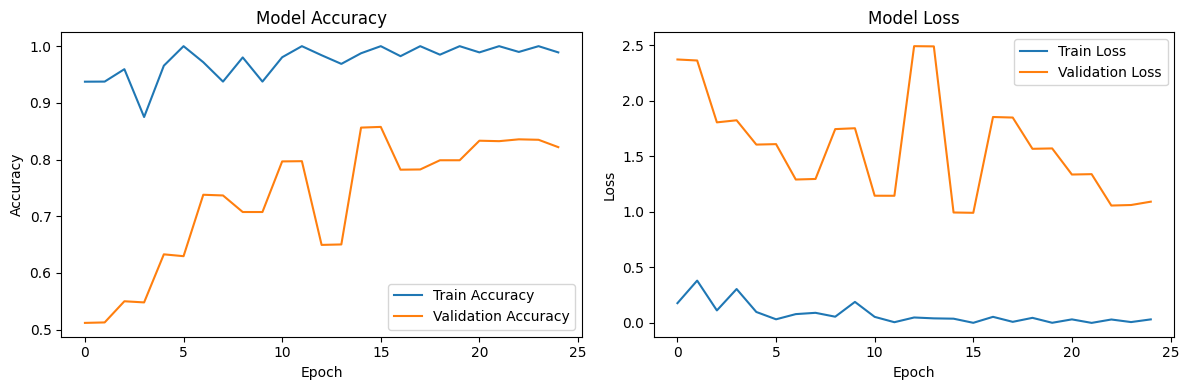

In [19]:
# 6. VISUALIZE TRAINING HISTORY
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


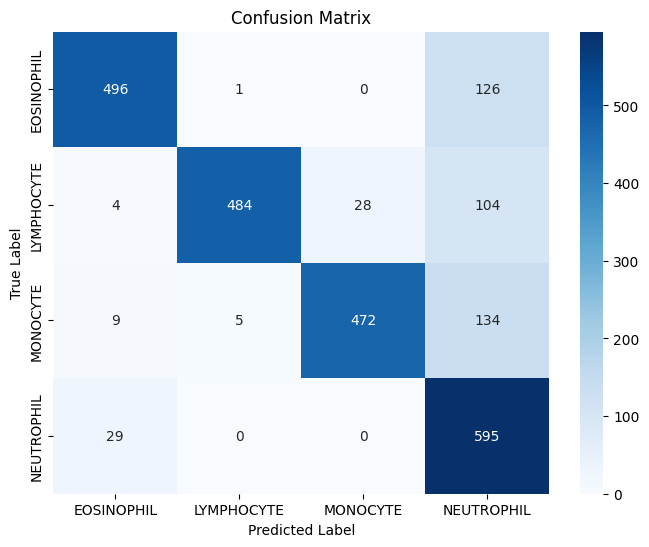

In [20]:
# 7. VISUAL CONFUSION MATRIX
cm = confusion_matrix(validation_generator.classes, val_preds_classes)
class_names = list(validation_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [25]:
# 8. SAVE THE MODEL
model.save('blood_cell_classifier.h5')
print("Model saved successfully as 'blood_cell_classifier.h5'")


Model saved successfully as 'blood_cell_classifier.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step


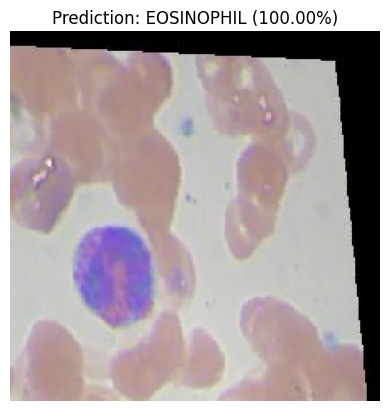

In [26]:
# 9. INFERENCE ON A SINGLE IMAGE
def predict_image(image_path, model, class_names):
    if not os.path.exists(image_path):
        print(f"Image path {image_path} does not exist.")
        return

    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Rescale

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()


class_names = list(train_generator.class_indices.keys())

sample_image_path = os.path.join(TEST_DIR, class_names[0], os.listdir(os.path.join(TEST_DIR, class_names[0]))[0])


predict_image(sample_image_path, model, class_names)
